<a href="https://colab.research.google.com/github/Pedro4Albuquerque/am-t4-s1a2026t2/blob/main/RegressionCensus0608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Regressão | Digest [Fase 1 census Base]

## Importar dados do Drive

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [95]:
!pip -q install plotly
!pip -q install yellowbrick

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [97]:
import pickle

In [98]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [99]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [100]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [101]:
from sklearn.linear_model import LogisticRegression

In [102]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_treinamento, Y_census_treinamento)

LogisticRegression(random_state=1)

In [103]:
LogisticRegression(C=1.0,class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty ='l2',
                   random_state=1, solver='lbfgs', tol =0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [104]:
regressao_previsoes = regressao_census.predict(X_census_teste)
regressao_previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [105]:
accuracy_score(Y_census_teste, regressao_census.predict(X_census_teste))

0.8497441146366428

In [106]:
from yellowbrick.classifier import ConfusionMatrix

0.8497441146366428

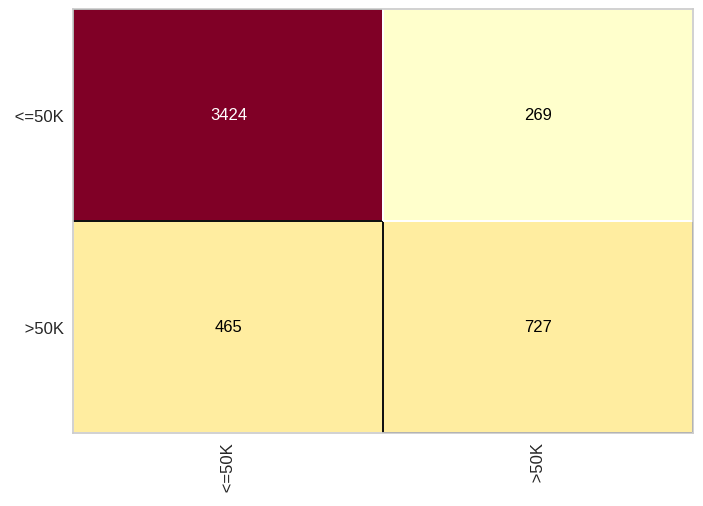

In [107]:
cm_census_reg = ConfusionMatrix(regressao_census)
cm_census_reg.fit(X_census_treinamento, Y_census_treinamento)
cm_census_reg.score(X_census_teste, Y_census_teste)

In [108]:
print(classification_report(Y_census_teste, regressao_census.predict(X_census_teste)))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885

